# Ansatz inspection

Draws the three socket circuits so their configuration can be checked by eye:
**L1** (parallel fan), **L2** (sequential entangler through the hub) and the
**product** control (L1 without CZ gates).

Both levels carry `15R+5` parameters — 20 / 35 / 50 at R = 1 / 2 / 3.

Barriers labelled `reupload i/R` mark where the R_y feature map is re-injected (data re-uploading). Barriers labelled `block i/R` and `closing Rx` mark the trainable layers. They come from `annotate=True` and are drawing aids only: the
circuits that run anywhere else carry no barriers at all.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from qsocket.ansatzes import (
    ANSATZ_REGISTRY,
    STAR_HUB_QUBIT,
    build_socket_circuit,
    socket_param_count,
    spoke_qubits,
)
from qsocket.encoding import FEATURE_RANGE, ry_feature_map
from qsocket.vendored.circuit_stats import count_gate_types

N_QUBITS = 5
print("hub qubit:", STAR_HUB_QUBIT, "| spokes:", spoke_qubits(N_QUBITS))
print("feature range:", FEATURE_RANGE)
print("parameters per R:", {R: socket_param_count(N_QUBITS, R) for R in (1, 2, 3)})

hub qubit: 2 | spokes: [0, 1, 3, 4]
feature range: (-0.7853981633974483, 0.7853981633974483)
parameters per R: {1: 20, 2: 35, 3: 50}


## Feature map

One R_y per qubit, one feature per qubit. The same `x` vector is reused at every re-upload.

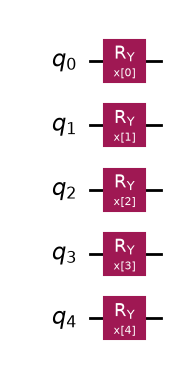

In [2]:
ry_feature_map(N_QUBITS).draw("mpl", fold=-1)

## The three circuits at R = 1

Read left to right: feature map, then the block, then the closing `Rx` layer.

Compare where the CZ gates sit. In **L1** they form one fan after two rotation layers,
with the third rotation layer *behind* the fan — in front of it that layer would be
diagonal like the fan itself, slide through, and merge with the tail. In **L2** the CZ
gates are interleaved with rotations on the hub, and the block ends *on a CZ*: a
trailing hub rotation would leave three angles where only two reach the measurement.

Note the second layer differs by axis: `Rx` in L1, `Ry` in L2. That is deliberate. In L2
an `Rx` there would sit next to the first `Rx(hub)` and merge with it, costing one
parameter per block.

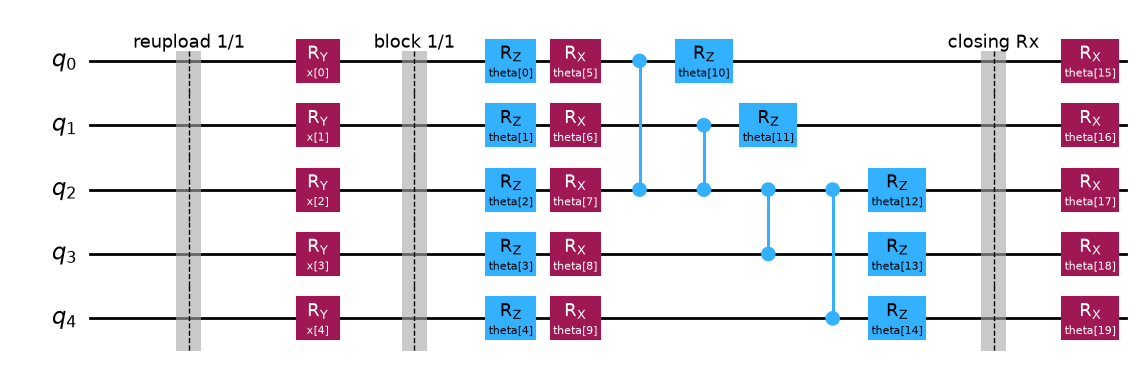

L1: 25 parameters (20 theta + 5 x)


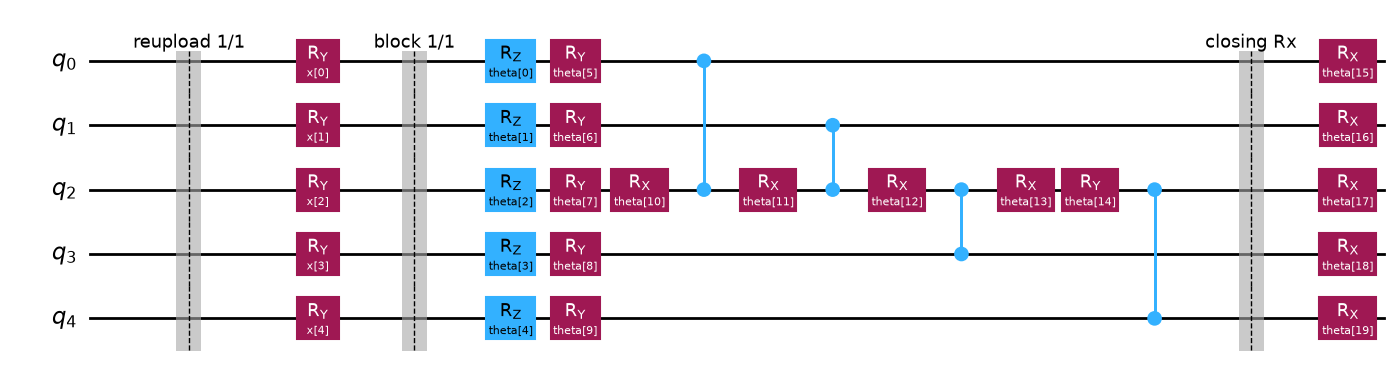

L2: 25 parameters (20 theta + 5 x)


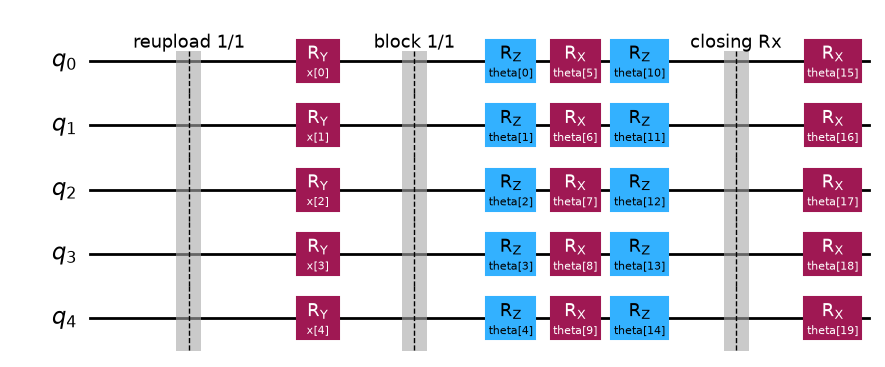

product: 25 parameters (20 theta + 5 x)


In [3]:
for name in ("L1", "L2", "product"):
    circuit = build_socket_circuit(name, N_QUBITS, 1, annotate=True)
    display(circuit.draw("mpl", fold=-1, style={"name": "iqp"}))
    print(f"{name}: {len(circuit.parameters)} parameters "
          f"({len([p for p in circuit.parameters if p.name.startswith('theta')])} theta + "
          f"{len([p for p in circuit.parameters if p.name.startswith('x')])} x)")

## Re-uploading at R = 2 and R = 3

Every `reupload i/R` barrier is a fresh injection of the same feature map. The number of
encoding gates is 5R while the number of distinct `x` parameters stays 5.

L2 also uses `Ry` for trainable rotations, so the encoding gates are counted by their
parameter, not by the gate name.

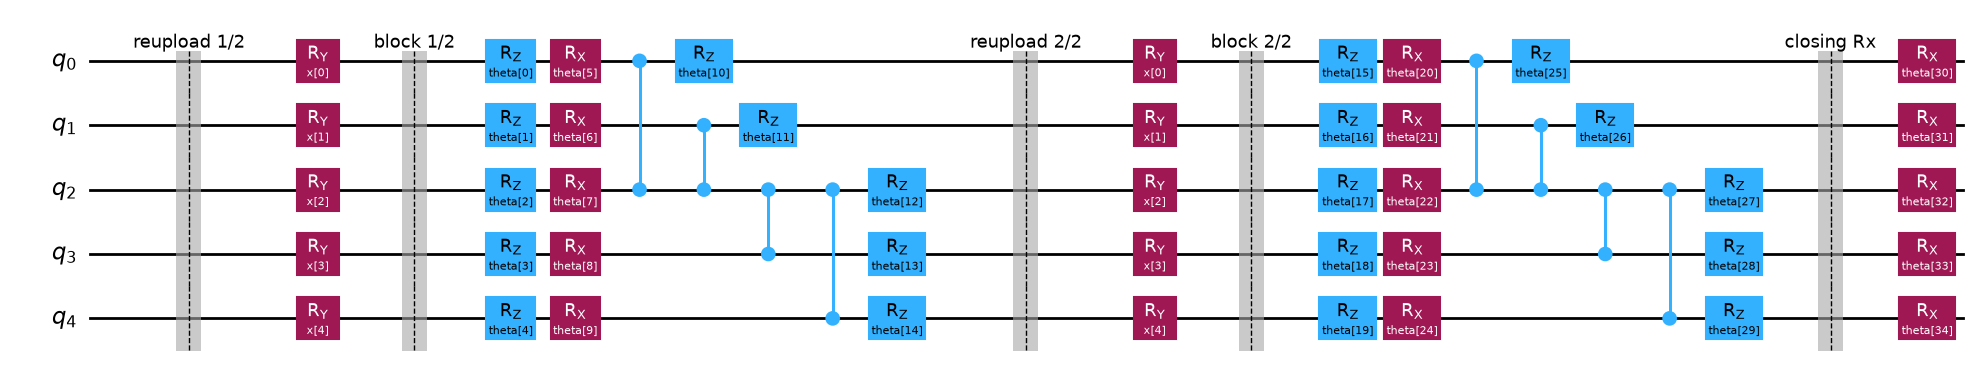

L1 R=2: encoding gates=10 (expected 10), cz=8 (expected 8), distinct x = 5


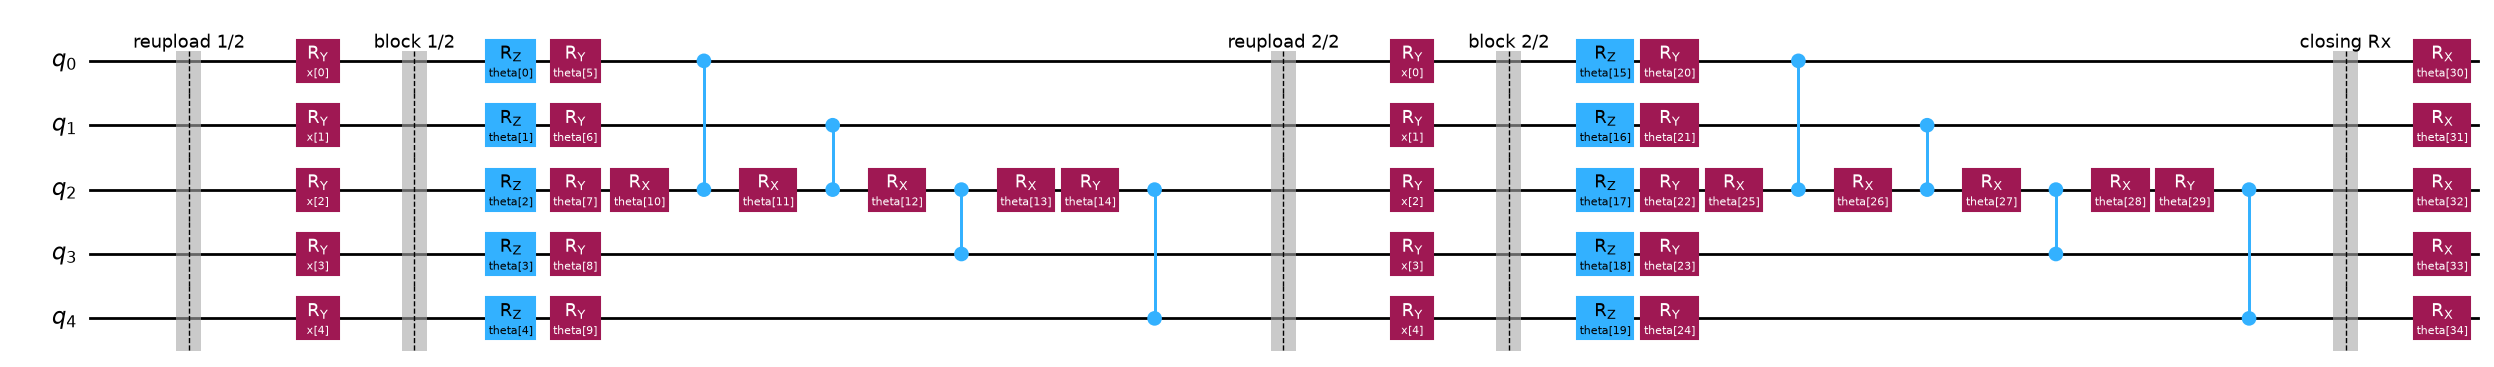

L2 R=2: encoding gates=10 (expected 10), cz=8 (expected 8), distinct x = 5


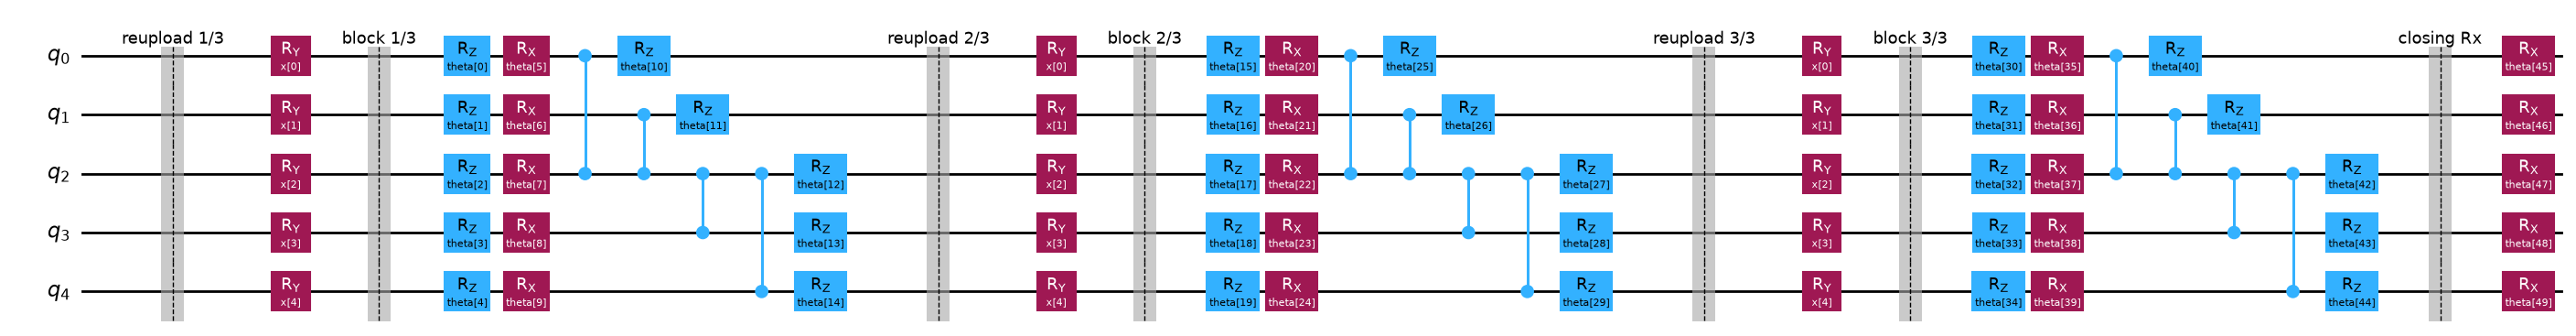

L1 R=3: encoding gates=15 (expected 15), cz=12 (expected 12), distinct x = 5


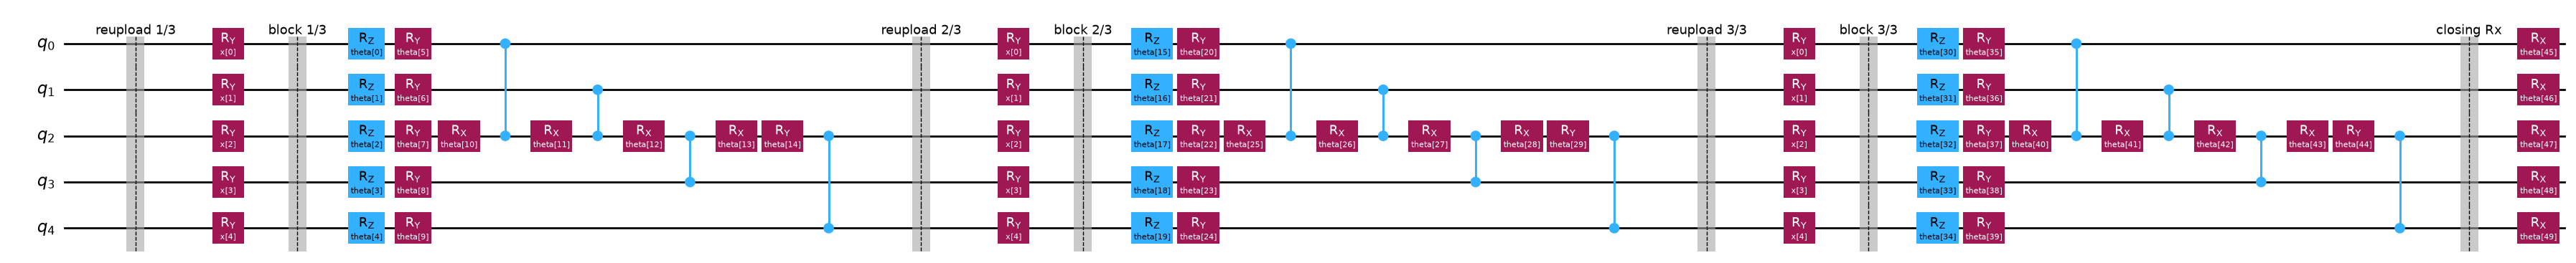

L2 R=3: encoding gates=15 (expected 15), cz=12 (expected 12), distinct x = 5


In [4]:
for R in (2, 3):
    for name in ("L1", "L2"):
        circuit = build_socket_circuit(name, N_QUBITS, R, annotate=True)
        display(circuit.draw("mpl", fold=-1, style={"name": "iqp"}))
        encoding = [
            instruction for instruction in circuit.data
            if instruction.operation.name == "ry"
            and any(p.name.startswith("x") for p in instruction.operation.params[0].parameters)
        ]
        ops = circuit.count_ops()
        print(f"{name} R={R}: encoding gates={len(encoding)} (expected {5 * R}), "
              f"cz={ops.get('cz', 0)} (expected {4 * R}), "
              f"distinct x = {len([p for p in circuit.parameters if p.name.startswith('x')])}")

## Gate inventory

Parameter counts, CZ counts and the qubit pairs actually used, straight from the vendored counter.

In [5]:
rows = []
for R in (1, 2, 3):
    for name in ANSATZ_REGISTRY:
        circuit = ANSATZ_REGISTRY[name](N_QUBITS, R)
        stats = count_gate_types(circuit)
        pairs = sorted(pair for pair, n in stats["Two-Qubit Gates by Pair"].items() if n)
        rows.append((name, R, len(circuit.parameters), stats["Single-Qubit Gates"],
                     stats["Two-Qubit Gates"], circuit.depth(), pairs))

print(f"{'ansatz':8s} {'R':>2s} {'theta':>6s} {'1q':>4s} {'2q':>4s} {'depth':>6s}  pairs")
for name, R, n_theta, one_q, two_q, depth, pairs in rows:
    print(f"{name:8s} {R:2d} {n_theta:6d} {one_q:4d} {two_q:4d} {depth:6d}  {pairs}")

ansatz    R  theta   1q   2q  depth  pairs
L1        1     20   20    4      8  [(0, 2), (1, 2), (2, 3), (2, 4)]
L2        1     20   20    4     12  [(0, 2), (1, 2), (2, 3), (2, 4)]
product   1     20   20    0      4  []
L1        2     35   35    8     15  [(0, 2), (1, 2), (2, 3), (2, 4)]
L2        2     35   35    8     23  [(0, 2), (1, 2), (2, 3), (2, 4)]
product   2     35   35    0      7  []
L1        3     50   50   12     22  [(0, 2), (1, 2), (2, 3), (2, 4)]
L2        3     50   50   12     34  [(0, 2), (1, 2), (2, 3), (2, 4)]
product   3     50   50    0     10  []


## Physical difference between the levels

Same theta, same x. If the two levels produced the same five expectation values, the
hub rotation in L2 would be commuting with the CZ gates and the levels would be one
level with two names.

In [6]:
from qiskit.quantum_info import Pauli, Statevector


def z_expectations(circuit, theta, x):
    values = {}
    for param in circuit.parameters:
        vector, index = param.name.split("[")
        index = int(index.rstrip("]"))
        values[param] = float(theta[index] if vector == "theta" else x[index])
    state = Statevector(circuit.assign_parameters(values))
    out = []
    for i in range(N_QUBITS):
        label = ["I"] * N_QUBITS
        label[N_QUBITS - 1 - i] = "Z"
        out.append(np.real(state.expectation_value(Pauli("".join(label)))))
    return np.array(out)


rng = np.random.default_rng(20260812)
R = 2
theta = rng.uniform(0, 2 * np.pi, socket_param_count(N_QUBITS, R))
x = rng.uniform(*FEATURE_RANGE, N_QUBITS)

z = {name: z_expectations(build_socket_circuit(name, N_QUBITS, R), theta, x)
     for name in ("L1", "L2", "product")}
for name, values in z.items():
    print(f"{name:8s} <Z_i> = {np.round(values, 4)}")
print(f"\nmax |L1 - L2| = {np.abs(z['L1'] - z['L2']).max():.6f}")

L1       <Z_i> = [-0.7999 -0.3897 -0.413  -0.6548  0.8507]
L2       <Z_i> = [-0.4793 -0.3799 -0.0796 -0.1525  0.7814]
product  <Z_i> = [ 0.796  -0.8905 -0.9619  0.5884  0.9767]

max |L1 - L2| = 0.502334


## Entanglement check

Maximum connected correlation `max_{i<j} |<Z_i Z_j> - <Z_i><Z_j>|`. Both levels must be
clearly above zero; the product circuit must be at numerical zero, which is the whole
reason it exists.

In [7]:
def max_connected_correlation(circuit, theta, x):
    values = {}
    for param in circuit.parameters:
        vector, index = param.name.split("[")
        index = int(index.rstrip("]"))
        values[param] = float(theta[index] if vector == "theta" else x[index])
    state = Statevector(circuit.assign_parameters(values))

    def pauli(*qubits):
        label = ["I"] * N_QUBITS
        for q in qubits:
            label[N_QUBITS - 1 - q] = "Z"
        return Pauli("".join(label))

    worst = 0.0
    for i in range(N_QUBITS):
        for j in range(i + 1, N_QUBITS):
            zz = np.real(state.expectation_value(pauli(i, j)))
            zi = np.real(state.expectation_value(pauli(i)))
            zj = np.real(state.expectation_value(pauli(j)))
            worst = max(worst, abs(zz - zi * zj))
    return worst


for name in ("L1", "L2", "product"):
    corr = max_connected_correlation(build_socket_circuit(name, N_QUBITS, R), theta, x)
    verdict = "entangling" if corr > 1e-3 else ("separable" if corr < 1e-5 else "AMBIGUOUS")
    print(f"{name:8s} max connected correlation = {corr:.3e}  -> {verdict}")

L1       max connected correlation = 2.048e-01  -> entangling
L2       max connected correlation = 1.800e-01  -> entangling
product  max connected correlation = 4.441e-16  -> separable


## Every parameter is used

The numerical rank of d⟨Z_i⟩/d(theta) counts the parameters that change anything. For
both levels it equals the nominal count at every R, so the socket has no parameter that
exists in `theta` and does nothing.

The product control sits lower on purpose: with no entangling gate each qubit carries a
single one-qubit unitary, and only two of its angles reach a Z measurement. That is just a
property of the control.

In [8]:
def jacobian_rank(circuit, X, theta, tol=1e-8):
    jac = np.empty((len(X) * N_QUBITS, len(theta)))
    for p in range(len(theta)):
        plus, minus = theta.copy(), theta.copy()
        plus[p] += np.pi / 2
        minus[p] -= np.pi / 2
        jac[:, p] = np.concatenate([
            (z_expectations(circuit, plus, x) - z_expectations(circuit, minus, x)) / 2 for x in X
        ])
    s = np.linalg.svd(jac, compute_uv=False)
    return int(np.sum(s > tol * s[0])), s


X = rng.uniform(*FEATURE_RANGE, size=(50, N_QUBITS))
for R in (1, 2, 3):
    th = rng.uniform(0, 2 * np.pi, socket_param_count(N_QUBITS, R))
    for name in ("L1", "L2", "product"):
        rank, _ = jacobian_rank(build_socket_circuit(name, N_QUBITS, R), X, th)
        nominal = socket_param_count(N_QUBITS, R)
        print(f"{name:8s} R={R}: rank {rank} / nominal {nominal}  -> {nominal - rank} dead directions")

L1       R=1: rank 20 / nominal 20  -> 0 dead directions
L2       R=1: rank 20 / nominal 20  -> 0 dead directions
product  R=1: rank 10 / nominal 20  -> 10 dead directions
L1       R=2: rank 35 / nominal 35  -> 0 dead directions
L2       R=2: rank 35 / nominal 35  -> 0 dead directions
product  R=2: rank 20 / nominal 35  -> 15 dead directions
L1       R=3: rank 50 / nominal 50  -> 0 dead directions
L2       R=3: rank 50 / nominal 50  -> 0 dead directions
product  R=3: rank 30 / nominal 50  -> 20 dead directions


### Singular-value spectrum

Both levels are full rank, so there is no gap between "alive" and "dead" to point at —
the honest check is instead how far the smallest singular value sits above the
threshold. It is five to six orders of magnitude above it, so the threshold is not
doing any of the work.

L1       s_min/s_max = 2.82e-03
L2       s_min/s_max = 1.60e-02
product  s_min/s_max = 1.18e-16


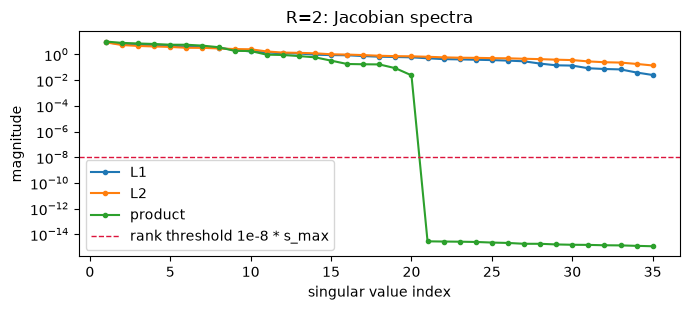

In [9]:
R = 2
th = rng.uniform(0, 2 * np.pi, socket_param_count(N_QUBITS, R))

fig, ax = plt.subplots(figsize=(7, 3.2))
for name in ("L1", "L2", "product"):
    _, s = jacobian_rank(build_socket_circuit(name, N_QUBITS, R), X, th)
    ax.semilogy(np.arange(1, len(s) + 1), np.maximum(s, 1e-18), "o-", ms=3, label=name)
    print(f"{name:8s} s_min/s_max = {s[-1] / s[0]:.2e}")
ax.axhline(1e-8, ls="--", lw=1, color="crimson", label="rank threshold 1e-8 * s_max")
ax.set_xlabel("singular value index")
ax.set_ylabel("magnitude")
ax.set_title("R=2: Jacobian spectra")
ax.legend()
fig.tight_layout()